# Examine Data Challenge Event Lightcurves

The purpose of this notebook is to plot the simulated event lightcurves from the data challenge dataset. 

In [1]:
from os import path
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, Column

In [2]:
DATA_DIR = '/Users/rstreet/Roman/data-challenge-1/lc'

Select the ID of the event to examine here.

In [3]:
eventID = 'ulwdc1_018'

Define t0 for this event so that an inset zoom-in plot can be created.  When this value is taken from the master_file.txt, which contains the values used in the original simulation, the t0 value needs to use the same offset as defined in the simulation.

In [4]:
t0 = 2458234.0 + 522.865948677

Load the two corresponding simulated lightcurve files

In [5]:
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')

In [6]:
def load_lc(file_path):
    """
    Function to load a lightcurve in the data challenge standard format. 

    Parameters:
        file_path str  Path to lightcurve text file 

    Returns:
        lc  Table   Lightcurve data table
    """

    if not path.isfile(file_path):
        raise IOError('Cannot find lightcurve file ' + file_path)

    data_table = Table.read(file_path, format='ascii')

    # Files do not contain column headers so we rename them for clarity
    data_table.rename_column('col1', 'JD')
    data_table.rename_column('col2', 'mag')
    data_table.rename_column('col3', 'mag_err')

    return data_table 

In [7]:
wlc = load_lc(wlc_path)
zlc = load_lc(zlc_path)
print(wlc)

      JD          mag    mag_err 
-------------- --------- --------
2458346.505461 19.912503  0.00596
2458346.515987 19.920534 0.006005
2458346.526513  19.90759 0.005933
 2458346.53704  19.91679 0.005984
2458346.547566 19.908758  0.00594
2458346.558093 19.903542 0.005911
2458346.568619 19.902874 0.005908
2458346.579145 19.909284 0.005943
2458346.589672 19.910716 0.005951
2458346.600198  19.91629 0.005981
           ...       ...      ...
2460059.146706 19.909517 0.005944
2460059.157232 19.928833 0.006051
2460059.167759 19.912679 0.005961
2460059.178285  19.89867 0.005885
2460059.188812 19.918528 0.005993
2460059.199338   19.9135 0.005966
2460059.209864 19.910775 0.005951
2460059.220391 19.904036 0.005914
2460059.230917 19.896848 0.005875
2460059.241444 19.906948  0.00593
Length = 38568 rows


Configure default plotting preferences

In [8]:
PLOT_COLORS = {
    'W149': '#03A66A',
    'Z087': '#2E03A6'
}

In [13]:
def plot_lc(wlc, zlc, inset_xmin, inset_xmax, plot_file, inset_left=0.35, inset_bottom=0.3, inset_width=0.6, inset_height=0.6):
    """
    Function to plot simulated Roman lightcurves, showing the full extent of the multi-season lightcurve plus 
    an inset box showing a zoom in lightcurve around the event peak. 

    Parameters:
        wlc  Table   Lightcurve data table for W146 filter 
        zlc  Table   Lightcurve data table for Z087 filter 
        inset_xmin float  Minimum x-range of the inset axis 
        inset_ymax float  Maximum x-range of the inset axis
        plot_file  str    File path for saved PNG plot
        inset_left float  [optional] Left-edge coordinate of inset box relative to the main axis [0-1] 
        inset_bottom float [optional] Bottom-edge coordinate of inset box 
        inset_width float [optional] Width of the inset box 
        inset_height float [optional] Height of the inset box


    Returns:
        None, output lightcurve saved to plot_file
    """
    
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
    
    dt = 2450000.0
    
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['W149'], label='W149')
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    axs.invert_yaxis()
    
    axs.set_xlabel('JD-2450000.0 [days]', fontsize=20) 
    axs.set_ylabel('Mag', fontsize=20)
    axs.set_title('Lightcurve for event ' + eventID, fontsize=20)
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    axs.grid()
    axs.legend(fontsize=18)
    
    # Add inset axes; coordinates are 0-1 relative to main axis 
    ax_inset = axs.inset_axes([inset_left, inset_bottom, inset_width, inset_height])
    
    ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['W149'], label='W149')
    ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    ax_inset.invert_yaxis()
    ax_inset.set_xlim(inset_xmin, inset_xmax)
    ax_inset.tick_params(axis='x', labelsize=16)
    ax_inset.tick_params(axis='y', labelsize=16)
    
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    ax_inset.grid()

    plt.tight_layout()
    
    plt.savefig(plot_file)

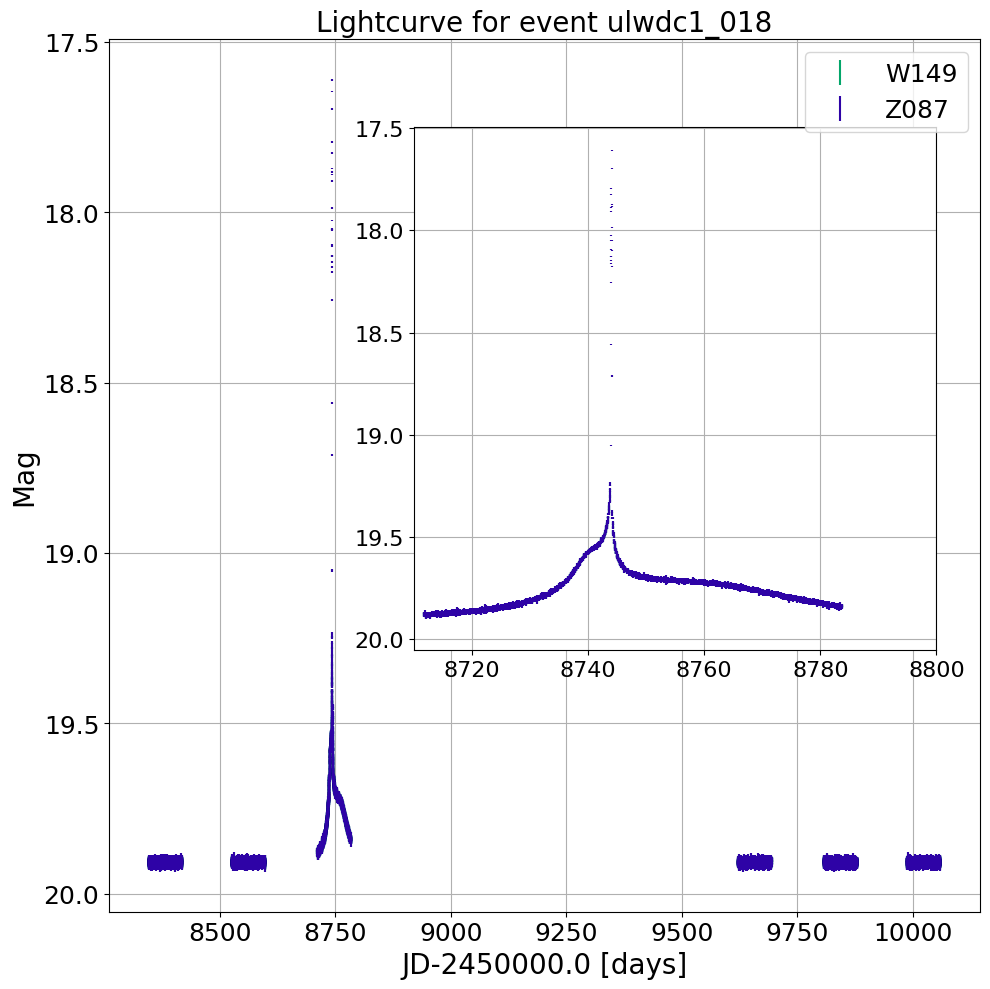

In [16]:
plot_file = path.join(DATA_DIR, eventID + '_lc.png')
plot_lc(wlc, zlc, 8710.0, 8800.0, plot_file, inset_left=0.35, inset_bottom=0.3, inset_width=0.6, inset_height=0.6)

Now let's explore some other example events that were not modeled by multiple teams (listed in missed_events_table.txt).

In [24]:
eventID = 'ulwdc1_166'
t0 = 2458234.0 + 354.602948427

In [25]:
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')

wlc = load_lc(wlc_path)
zlc = load_lc(zlc_path)

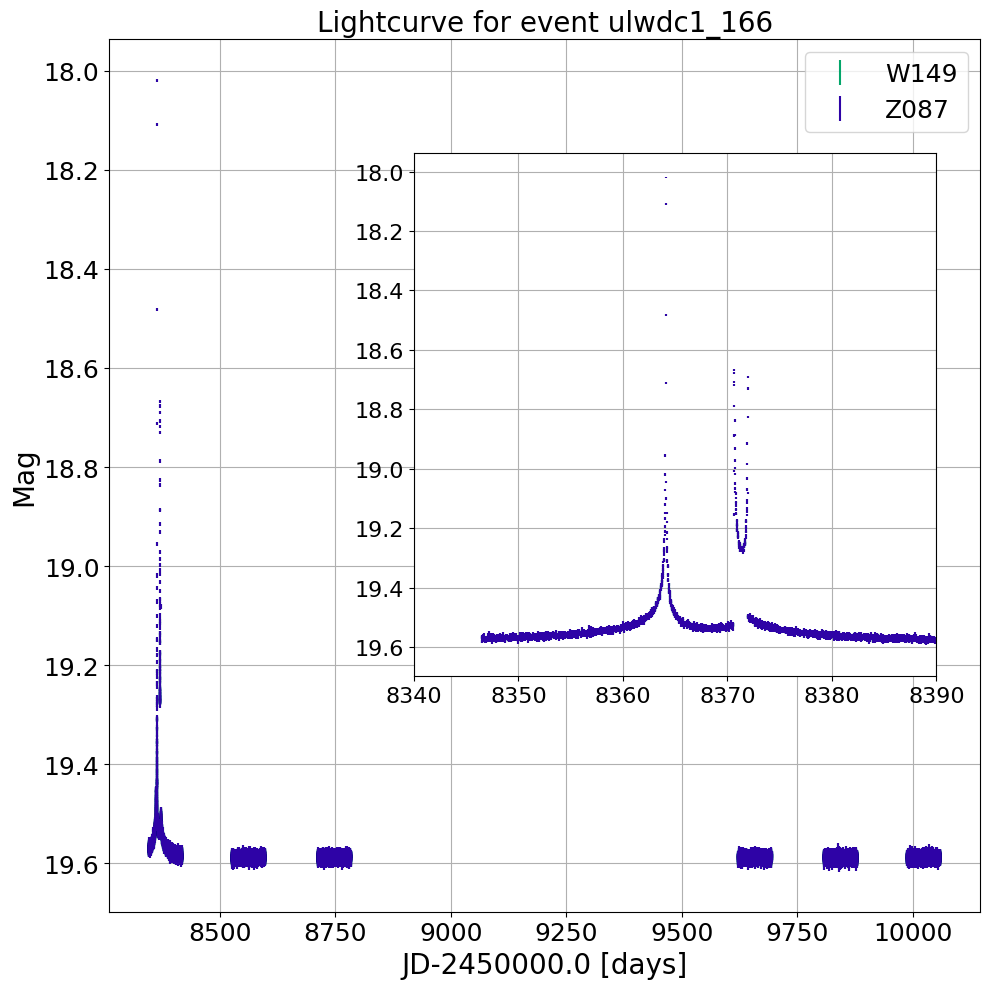

In [26]:
plot_file = path.join(DATA_DIR, eventID + '_lc.png')
plot_lc(wlc, zlc, 8340.0, 8390.0, plot_file, inset_left=0.35, inset_bottom=0.27, inset_width=0.6, inset_height=0.6)

In [20]:
eventID = 'ulwdc1_282'

In [ ]:
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')

wlc = load_lc(wlc_path)
zlc = load_lc(zlc_path)

In [ ]:
plot_file = path.join(DATA_DIR, eventID + '_lc.png')
plot_lc(wlc, zlc, 8520.0, 8600.0, plot_file, inset_left=0.35, inset_bottom=0.3, inset_width=0.6, inset_height=0.6)